In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

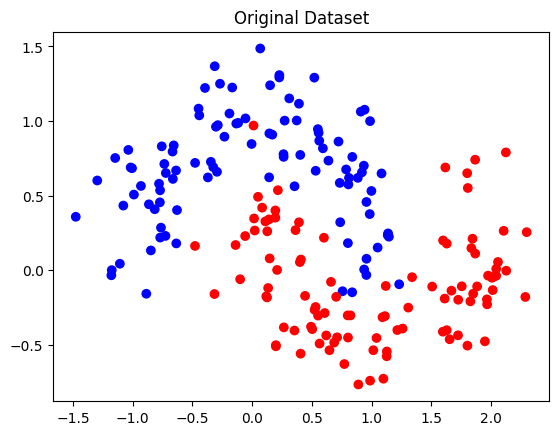

In [4]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
plt.title("Original Dataset")
plt.show()

In [6]:
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

model = LogisticRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)

In [7]:
print("Accuracy:", accuracy_score(y, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y, y_pred))

Accuracy: 0.945
Confusion Matrix:
 [[93  7]
 [ 4 96]]


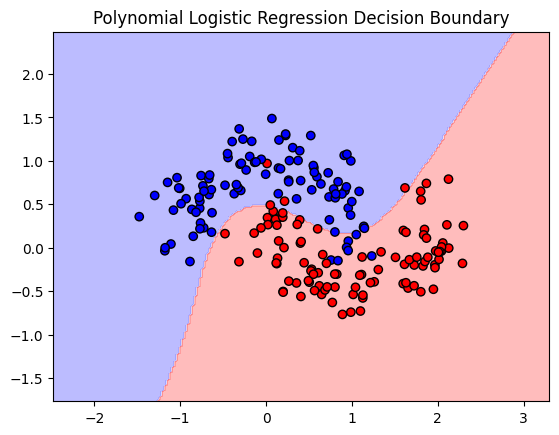

In [8]:

def plot_decision_boundary(X, y, model, poly):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Transform grid points with polynomial features
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_poly = poly.transform(grid)
    
    Z = model.predict(grid_poly)
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, cmap='bwr', alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k')
    plt.title("Polynomial Logistic Regression Decision Boundary")
    plt.show()

plot_decision_boundary(X, y, model, poly)
